<a href="https://colab.research.google.com/github/KapoorAkshit18/RISCV-VDP-SoC/blob/main/RISCV-VDP-SoC/phases/Python_Visualisation/Analysis_RVSoC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## RISC-V SoC VCD Waveform Analysis

### 1. Load Data and Initial Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_file(filepath, file_type='csv', skip_footer=0):
    if file_type == 'csv':
        df = pd.read_csv(filepath, skipfooter=skip_footer, engine='python', encoding='latin1')
    elif file_type == 'xlsx':
        df = pd.read_excel(filepath)
        # Explicitly trim the dataframe for XLSX as read_excel doesn't have skipfooter
        if skip_footer > 0:
            # Ensure a copy to prevent SettingWithCopyWarning
            df = df.iloc[:-skip_footer].copy()
    else:
        raise ValueError("Unsupported file type. Must be 'csv' or 'xlsx'.")

    # Remove any potential whitespace from column names
    df.columns = df.columns.str.strip()

    # Ensure 'Cycle' and 'Global_Distance' are numeric
    if 'Cycle' in df.columns:
        df['Cycle'] = pd.to_numeric(df['Cycle'], errors='coerce')
    if 'Global_Distance' in df.columns:
        df['Global_Distance'] = pd.to_numeric(df['Global_Distance'], errors='coerce')

    # Drop rows where 'Cycle' or 'Global_Distance' are NaN
    # This addresses any remaining footer rows or malformed entries that converted to NaN
    initial_rows = df.shape[0]
    df.dropna(subset=['Cycle', 'Global_Distance'], inplace=True)
    if df.shape[0] < initial_rows:
        print(f"Dropped {initial_rows - df.shape[0]} rows with NaN in 'Cycle' or 'Global_Distance' for {filepath}.")

    # After dropping NaNs, these columns should be clean for integer conversion
    if 'Cycle' in df.columns:
        df['Cycle'] = df['Cycle'].astype(int)
    if 'Global_Distance' in df.columns:
        df['Global_Distance'] = df['Global_Distance'].astype(int)

    # Handle hex string conversion for value columns and convert d_<signal> to numeric
    for col in df.columns:
        if col.startswith('d_') and df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
        elif df[col].dtype == 'object':
            # Check if column is object type and contains hex strings
            # Create a new column for integer representation if it's a hex string
            # Otherwise, attempt to convert to numeric if appropriate

            # Identify which values are hex strings (start with '0x')
            is_hex = df[col].astype(str).str.startswith('0x')

            # Create the '_int' column only if there are actual hex values
            if is_hex.any():
                df[col + '_int'] = df[col].apply(
                    lambda x: int(x, 16) if isinstance(x, str) and str(x).startswith('0x') else np.nan
                )

            # For the original column, try to convert to numeric if it's not a hex string
            # This handles cases where object columns might contain numbers or other strings
            df[col] = pd.to_numeric(df[col], errors='ignore')
            # If after pd.to_numeric with errors='ignore', it's still object and has a mix,
            # we leave it as is. If it successfully converted to numeric, its dtype would change.

    return df

# --- Rename the misnamed file first ---
# This command is idempotent, so it won't cause issues if the file was already renamed.
!mv -f /content/sgns_riscvram.csv /content/sgns_riscvram.xlsx

# Load both datasets
# Adjusted skip_footer for the baseline XLSX file based on inspection (145 total rows - 101 data rows = 44 footer rows)
df_baseline = load_and_preprocess_file('/content/sgns_riscvram.xlsx', file_type='xlsx', skip_footer=44)
df_tpu = load_and_preprocess_file('/content/sgns_with_tpu.csv', file_type='csv')

print("Baseline DataFrame (sgns_riscvram.xlsx):")
display(df_baseline.head())
print("\nInfo for Baseline DataFrame:")
df_baseline.info()

print("\n\nTPU-integrated DataFrame (sgns_with_tpu.csv):")
display(df_tpu.head())
print("\nInfo for TPU-integrated DataFrame:")
df_tpu.info()

Dropped 1 rows with NaN in 'Cycle' or 'Global_Distance' for /content/sgns_riscvram.xlsx.


/tmp/ipykernel_1105/3048622646.py:60: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_1105/3048622646.py:60: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_1105/3048622646.py:60: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_1105/3048622646.py:60: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignor

Baseline DataFrame (sgns_riscvram.xlsx):


/tmp/ipykernel_1105/3048622646.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + '_int'] = df[col].apply(
/tmp/ipykernel_1105/3048622646.py:60: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


,Cycle,Global_Distance,dbg_ascii_instr[63:0],d_dbg_ascii_instr[63:0],resetn,d_resetn,trap,d_trap,dbg_rs1val[31:0],d_dbg_rs1val[31:0],...,mem_addr[31:0],d_mem_addr[31:0],mem_wstrb[3:0],d_mem_wstrb[3:0],mem_rdata[31:0],d_mem_rdata[31:0],reg_pc[31:0],d_reg_pc[31:0],dbg_insn_opcode[31:0],d_dbg_insn_opcode[31:0]
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Info for Baseline DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Cycle                    100 non-null    int64 
 1   Global_Distance          100 non-null    int64 
 2   dbg_ascii_instr[63:0]    100 non-null    object
 3   d_dbg_ascii_instr[63:0]  100 non-null    int64 
 4   resetn                   100 non-null    int64 
 5   d_resetn                 100 non-null    int64 
 6   trap                     100 non-null    int64 
 7   d_trap                   100 non-null    int64 
 8   dbg_rs1val[31:0]         100 non-null    int64 
 9   d_dbg_rs1val[31:0]       100 non-null    int64 
 10  dbg_rs2val[31:0]         100 non-null    int64 
 11  d_dbg_rs2val[31:0]       100 non-null    int64 
 12  cpu_state[7:0]           100 non-null    int64 
 13  d_cpu_state[7:0]         100 non-null    int64 
 14  mem_valid         

,Cycle,Global_Distance,tb_cpu_soc_ram_top.pixel_clk,d_tb_cpu_soc_ram_top.pixel_clk,tb_cpu_soc_ram_top.resetn,d_tb_cpu_soc_ram_top.resetn,tb_cpu_soc_ram_top.dut.clk,d_tb_cpu_soc_ram_top.dut.clk,tb_cpu_soc_ram_top.dut.resetn,d_tb_cpu_soc_ram_top.dut.resetn,...,tb_cpu_soc_ram_top.sensor_valid_i_int,tb_cpu_soc_ram_top.rssi_dbm_i_int,tb_cpu_soc_ram_top.link_up_i_int,tb_cpu_soc_ram_top.link_error_i_int,tb_cpu_soc_ram_top.carrier_detect_i_int,tb_cpu_soc_ram_top.tb_m_valid_int,tb_cpu_soc_ram_top.tb_m_write_int,tb_cpu_soc_ram_top.tb_m_addr_int,tb_cpu_soc_ram_top.tb_m_wdata_int,tb_cpu_soc_ram_top.tb_m_strb_int
0,0,0,0x0,0,0x0,0,0x1,0,0x0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0x0,0,0x0,0,0x1,0,0x0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,1,0x1,1,0x0,0,0x1,0,0x0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0x1,0,0x0,0,0x1,0,0x0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,4,0x0,1,0x1,1,0x1,0,0x1,1,...,0,0,0,0,0,0,0,0,0,0



Info for TPU-integrated DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8196 entries, 0 to 8195
Columns: 239 entries, Cycle to tb_cpu_soc_ram_top.tb_m_strb_int
dtypes: int64(154), object(79), uint64(6)
memory usage: 14.9+ MB


## Analysis Tasks

### 1. TPU Latency Measurement

In [ ]:
def tpu_latency_measurement(df, start_signal, done_signal, input_tvalid, input_tready, output_tvalid, output_tready, clock_period_ns=10):
    latency_results = []

    # 1. TPU Latency: axis_start to axis_done
    # Ensure the columns exist before proceeding
    if start_signal in df.columns and done_signal in df.columns:
        # Ensure the columns are numeric before comparison
        start_series = pd.to_numeric(df[start_signal], errors='coerce').fillna(0)
        done_series = pd.to_numeric(df[done_signal], errors='coerce').fillna(0)

        start_edges = df[(start_series.shift(1) == 0) & (start_series == 1)]
        done_edges = df[(done_series.shift(1) == 0) & (done_series == 1)]

        for _, start_row in start_edges.iterrows():
            start_cycle = start_row['Cycle']
            # Find the next done_edge after the start_edge
            next_done = done_edges[done_edges['Cycle'] > start_cycle]
            if not next_done.empty:
                done_cycle = next_done.iloc[0]['Cycle']
                latency_cycles = done_cycle - start_cycle
                latency_ns = latency_cycles * clock_period_ns
                latency_results.append({
                    'Operation': 'TPU Core Latency',
                    'Start_Cycle': start_cycle,
                    'End_Cycle': done_cycle,
                    'Latency_Cycles': latency_cycles,
                    'Latency_ns': latency_ns
                })
    else:
        print(f"Warning: TPU core latency signals '{start_signal}' or '{done_signal}' not found in DataFrame.")

    # 2. AXI-Stream Latency: input handshake to output handshake
    # Ensure the columns exist before proceeding
    if (input_tvalid in df.columns and input_tready in df.columns and
        output_tvalid in df.columns and output_tready in df.columns):

        # Ensure the columns are numeric before comparison
        input_tvalid_series = pd.to_numeric(df[input_tvalid], errors='coerce').fillna(0)
        input_tready_series = pd.to_numeric(df[input_tready], errors='coerce').fillna(0)
        output_tvalid_series = pd.to_numeric(df[output_tvalid], errors='coerce').fillna(0)
        output_tready_series = pd.to_numeric(df[output_tready], errors='coerce').fillna(0)

        input_handshakes = df[(input_tvalid_series == 1) & (input_tready_series == 1)]
        output_handshakes = df[(output_tvalid_series == 1) & (output_tready_series == 1)]

        for _, in_hs_row in input_handshakes.iterrows():
            in_hs_cycle = in_hs_row['Cycle']
            # Find the first output handshake after the input handshake
            next_out_hs = output_handshakes[output_handshakes['Cycle'] > in_hs_cycle]
            if not next_out_hs.empty:
                out_hs_cycle = next_out_hs.iloc[0]['Cycle']
                latency_cycles = out_hs_cycle - in_hs_cycle
                latency_ns = latency_cycles * clock_period_ns
                latency_results.append({
                    'Operation': 'AXI-Stream Latency',
                    'Start_Cycle': in_hs_cycle,
                    'End_Cycle': out_hs_cycle,
                    'Latency_Cycles': latency_cycles,
                    'Latency_ns': latency_ns
                })
    else:
        print(f"Warning: AXI-Stream signals missing for latency measurement in DataFrame.")

    return pd.DataFrame(latency_results)

# --- Apply to df_tpu ---
# Assuming 10ns/cycle @ 100MHz
clock_period_ns = 10

# Corrected signal names to use the _int suffixed columns
tpu_start_signal = 'tb_cpu_soc_ram_top.dut.tpu.axis_start_int'
tpu_done_signal = 'tb_cpu_soc_ram_top.dut.tpu.axis_done_int'

axi_input_tvalid = 'tb_cpu_soc_ram_top.dut.tpu.in_tvalid_int'
axi_input_tready = 'tb_cpu_soc_ram_top.dut.tpu.in_tready_int'
axi_output_tvalid = 'tb_cpu_soc_ram_top.dut.tpu.out_tvalid_int'
axi_output_tready = 'tb_cpu_soc_ram_top.dut.tpu.out_tready_int'

# Only run if df_tpu contains the necessary columns
if (tpu_start_signal in df_tpu.columns and tpu_done_signal in df_tpu.columns) or \
   (axi_input_tvalid in df_tpu.columns and axi_input_tready in df_tpu.columns and
    axi_output_tvalid in df_tpu.columns and axi_output_tready in df_tpu.columns):

    tpu_latency_df = tpu_latency_measurement(
        df_tpu,
        start_signal=tpu_start_signal,
        done_signal=tpu_done_signal,
        input_tvalid=axi_input_tvalid,
        input_tready=axi_input_tready,
        output_tvalid=axi_output_tvalid,
        output_tready=axi_output_tready,
        clock_period_ns=clock_period_ns
    )
    print("TPU Latency Measurement Results:")
    display(tpu_latency_df)
else:
    print("Skipping TPU Latency Measurement as required signals are not present in df_tpu.")

TPU Latency Measurement Results:


,Operation,Start_Cycle,End_Cycle,Latency_Cycles,Latency_ns
0,TPU Core Latency,294,353,59,590
1,AXI-Stream Latency,295,350,55,550
2,AXI-Stream Latency,296,350,54,540
3,AXI-Stream Latency,297,350,53,530
4,AXI-Stream Latency,298,350,52,520
5,AXI-Stream Latency,299,350,51,510
6,AXI-Stream Latency,300,350,50,500
7,AXI-Stream Latency,301,350,49,490


### 2. Activity/Switching Profile

--- Baseline Activity/Switching Profile ---


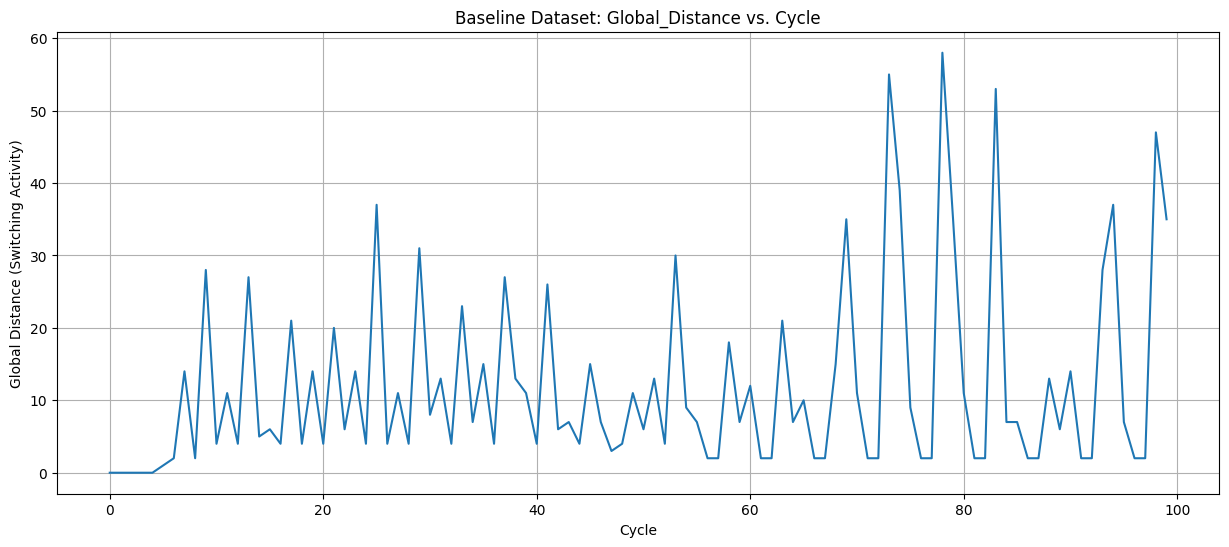


Summary Statistics for Global_Distance in Baseline Dataset:


,Global_Distance
count,100.000000
mean,11.960000
std,13.114045
min,0.000000
25%,2.000000
50%,7.000000
75%,14.250000
max,58.000000



Top 10 High-Activity Cycles (Baseline):


,Cycle,Global_Distance
78,78,58
73,73,55
83,83,53
98,98,47
74,74,39
25,25,37
94,94,37
79,79,35
69,69,35
99,99,35



--- TPU-integrated Activity/Switching Profile ---


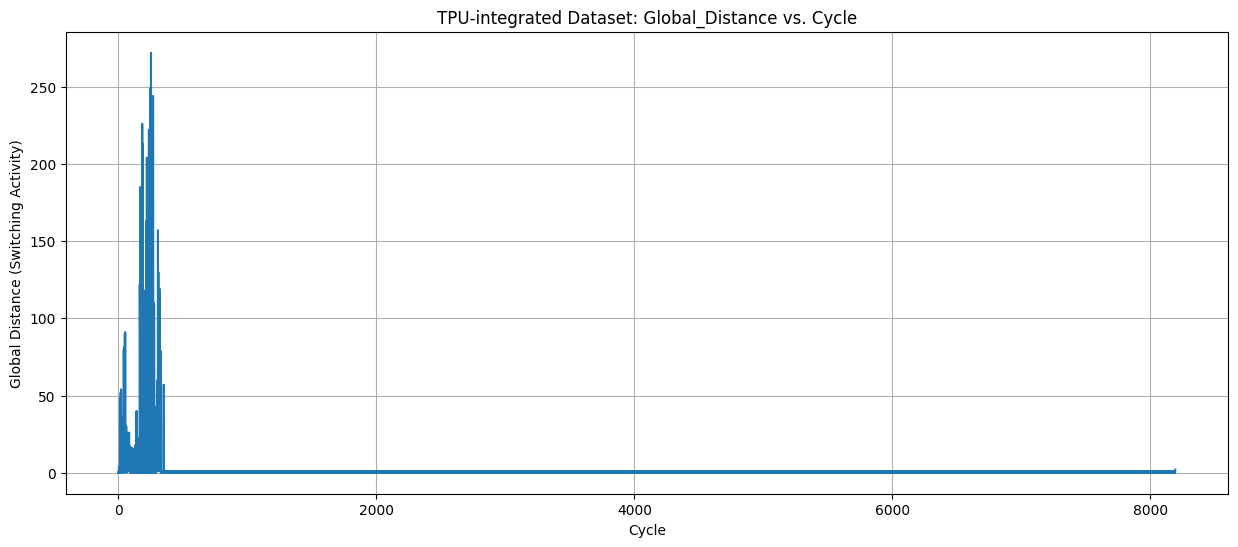


Summary Statistics for Global_Distance in TPU-integrated Dataset:


,Global_Distance
count,8196.000000
mean,1.951074
std,12.582639
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,272.000000



Top 10 High-Activity Cycles (TPU-integrated):


,Cycle,Global_Distance
252,252,272
248,248,249
268,268,244
184,184,226
236,236,222
188,188,213
220,220,204
168,168,185
249,249,177
264,264,176


In [ ]:
def plot_global_distance(df, title):
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=df, x='Cycle', y='Global_Distance')
    plt.title(f'{title}: Global_Distance vs. Cycle')
    plt.xlabel('Cycle')
    plt.ylabel('Global Distance (Switching Activity)')
    plt.grid(True)
    plt.show()

def get_high_activity_cycles(df, num_cycles=10):
    # Sort by Global_Distance in descending order and get the top N cycles
    top_cycles = df.sort_values(by='Global_Distance', ascending=False).head(num_cycles)
    return top_cycles[['Cycle', 'Global_Distance']]

def summarize_global_distance(df, title):
    summary = df['Global_Distance'].describe()
    print(f"\nSummary Statistics for Global_Distance in {title}:")
    display(summary)

# --- Apply to df_baseline ---
print("--- Baseline Activity/Switching Profile ---")
plot_global_distance(df_baseline, 'Baseline Dataset')
summarize_global_distance(df_baseline, 'Baseline Dataset')
print("\nTop 10 High-Activity Cycles (Baseline):")
display(get_high_activity_cycles(df_baseline, 10))

# --- Apply to df_tpu ---
print("\n--- TPU-integrated Activity/Switching Profile ---")
plot_global_distance(df_tpu, 'TPU-integrated Dataset')
summarize_global_distance(df_tpu, 'TPU-integrated Dataset')
print("\nTop 10 High-Activity Cycles (TPU-integrated):")
display(get_high_activity_cycles(df_tpu, 10))

### 3. Per-Module Activity Breakdown

--- Baseline Per-Module Activity Breakdown ---


,0
dbg_rs1val,339
dbg_ascii_instr,189
dbg_insn_opcode,163
mem_rdata,163
cpu_state,142
mem_valid,43
mem_ready,42
mem_addr,39
reg_pc,38
dbg_rs2val,36


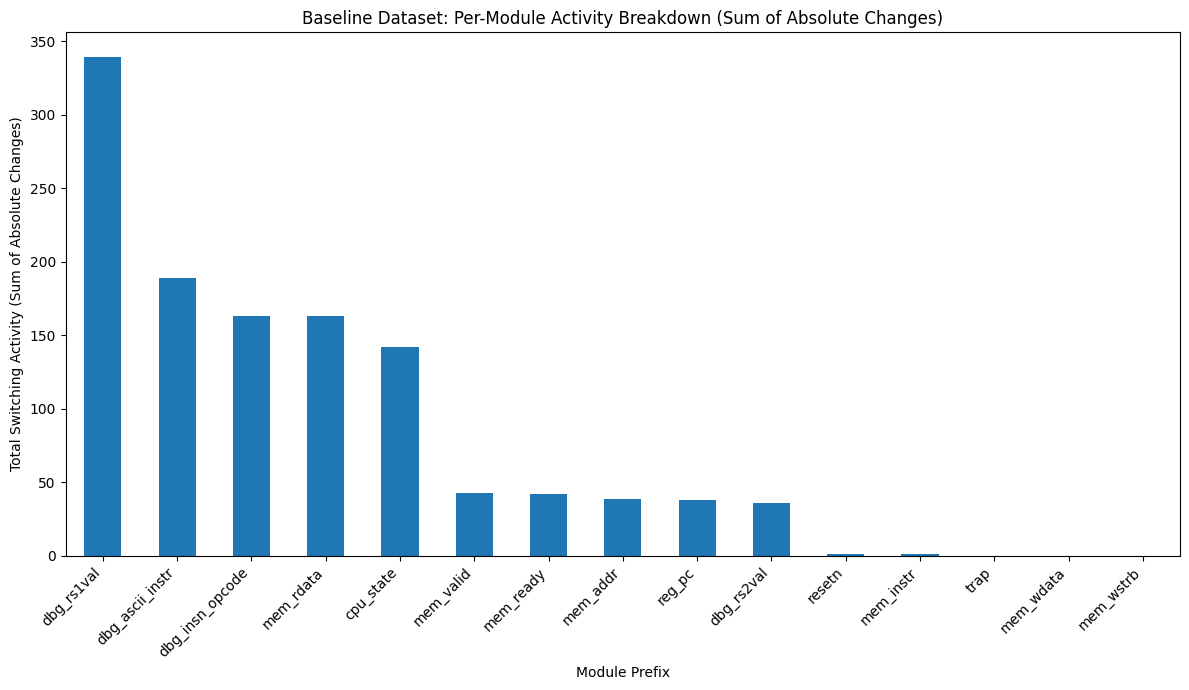


--- TPU-integrated Per-Module Activity Breakdown ---


,0
tb_cpu_soc_ram_top,5776
tb_cpu_soc_ram_top.dut.tpu,4600
tb_cpu_soc_ram_top.dut.m_rdata,1682
tb_cpu_soc_ram_top.dut.nn_rdata,1042
tb_cpu_soc_ram_top.dut.m_wdata,740
tb_cpu_soc_ram_top.dut.m_addr,517
tb_cpu_soc_ram_top.dut.nn_wdata,486
tb_cpu_soc_ram_top.dut.m_strb,192
tb_cpu_soc_ram_top.dut.nn_addr,162
tb_cpu_soc_ram_top.dut.m_ready,150


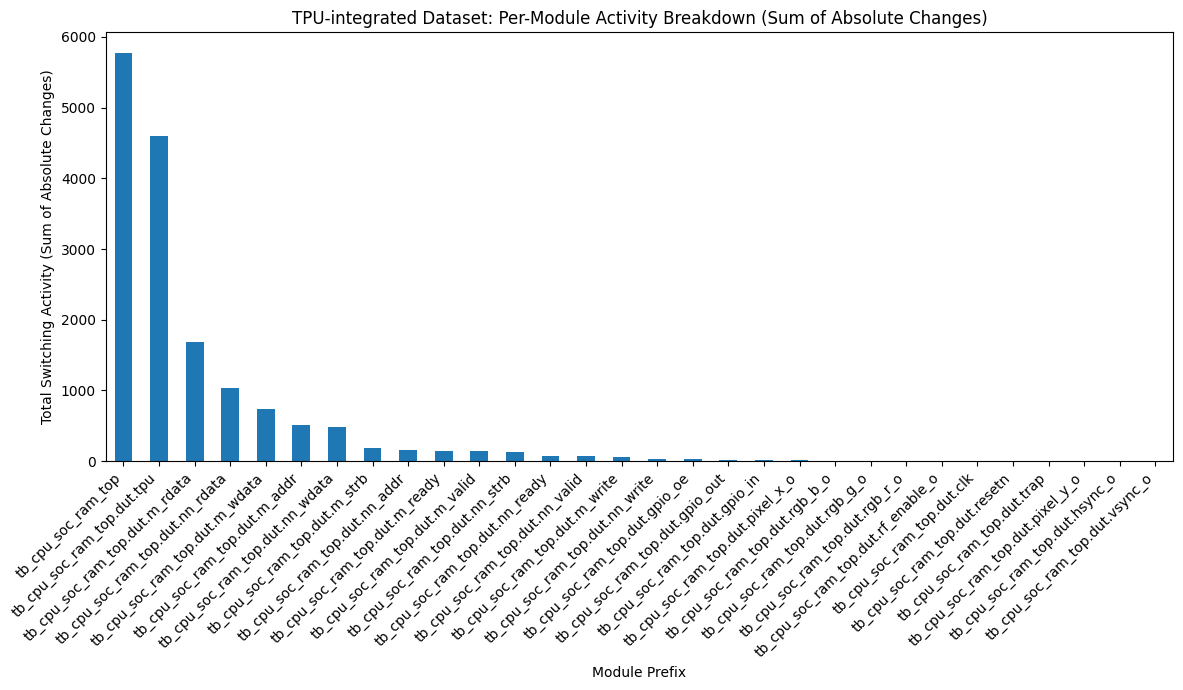

In [ ]:
def get_module_activity(df):
    module_activity = {}
    # Iterate through columns, skipping 'Cycle', 'Global_Distance', '_int' columns, and 'd_' columns themselves
    for col in df.columns:
        if col not in ['Cycle', 'Global_Distance'] and not col.endswith('_int') and not col.startswith('d_'):
            # Determine prefix based on column naming conventions
            module_prefix = None
            if '.' in col:
                parts = col.split('.')
                # Try to get module up to dut.tpu or similar if 'dut' is present
                if 'dut' in parts:
                    try:
                        dut_idx = parts.index('dut')
                        if dut_idx + 1 < len(parts):
                            module_prefix = '.'.join(parts[:dut_idx+2]) # e.g., 'tb_cpu_soc_ram_top.dut.tpu'
                        else:
                            module_prefix = '.'.join(parts[:dut_idx+1]) # just 'tb_cpu_soc_ram_top.dut'
                    except ValueError:
                        # Should not happen if 'dut' in parts, but as a safeguard
                        pass
                if not module_prefix: # Fallback for dot-separated names if no specific 'dut' rule applies
                    module_prefix = parts[0] # Take the top-level module part before the first dot
            else:
                # Handle names without dots (like in df_baseline)
                # Look for signal range brackets like [63:0]
                bracket_idx = col.find('[')
                if bracket_idx != -1:
                    module_prefix = col[:bracket_idx] # Use the part before the bracket
                else:
                    module_prefix = col # Use the whole name if no dots or brackets

            if module_prefix:
                delta_col = 'd_' + col
                if delta_col in df.columns:
                    # Sum the absolute changes for activity
                    # Ensure delta_col is numeric, it should be from preprocessing
                    activity = pd.to_numeric(df[delta_col], errors='coerce').abs().sum()
                    if module_prefix in module_activity:
                        module_activity[module_prefix] += activity
                    else:
                        module_activity[module_prefix] = activity

    return pd.Series(module_activity).sort_values(ascending=False)

def plot_module_activity(module_series, title):
    plt.figure(figsize=(12, 7))
    module_series.plot(kind='bar')
    plt.title(f'{title}: Per-Module Activity Breakdown (Sum of Absolute Changes)')
    plt.xlabel('Module Prefix')
    plt.ylabel('Total Switching Activity (Sum of Absolute Changes)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- Apply to df_baseline ---
print("--- Baseline Per-Module Activity Breakdown ---")
baseline_module_activity = get_module_activity(df_baseline)
display(baseline_module_activity)
plot_module_activity(baseline_module_activity, 'Baseline Dataset')

# --- Apply to df_tpu ---
print("\n--- TPU-integrated Per-Module Activity Breakdown ---")
tpu_module_activity = get_module_activity(df_tpu)
display(tpu_module_activity)
plot_module_activity(tpu_module_activity, 'TPU-integrated Dataset')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 4. Dataset Comparison

In [ ]:
def compare_datasets(df_baseline, df_tpu, name_baseline='Baseline', name_tpu='TPU-integrated'):
    comparison_data = []

    # Total Cycle Count
    total_cycles_baseline = df_baseline['Cycle'].max() + 1
    total_cycles_tpu = df_tpu['Cycle'].max() + 1
    comparison_data.append({
        'Metric': 'Total Cycle Count',
        name_baseline: total_cycles_baseline,
        name_tpu: total_cycles_tpu
    })

    # Total Global_Distance
    total_gd_baseline = df_baseline['Global_Distance'].sum()
    total_gd_tpu = df_tpu['Global_Distance'].sum()
    comparison_data.append({
        'Metric': 'Total Global Distance',
        name_baseline: total_gd_baseline,
        name_tpu: total_gd_tpu
    })

    # Average Global_Distance per Cycle
    avg_gd_baseline = df_baseline['Global_Distance'].mean()
    avg_gd_tpu = df_tpu['Global_Distance'].mean()
    comparison_data.append({
        'Metric': 'Average Global Distance per Cycle',
        name_baseline: avg_gd_baseline,
        name_tpu: avg_gd_tpu
    })

    comparison_df = pd.DataFrame(comparison_data)

    # Calculate TPU Overhead (as percentage increase for now)
    for index, row in comparison_df.iterrows():
        baseline_val = row[name_baseline]
        tpu_val = row[name_tpu]
        if baseline_val != 0:
            overhead = ((tpu_val - baseline_val) / baseline_val) * 100
            comparison_df.loc[index, 'TPU Overhead (%)'] = overhead
        else:
            comparison_df.loc[index, 'TPU Overhead (%)'] = np.nan # Or 0 if tpu_val is also 0

    return comparison_df

print("--- Dataset Comparison ---")
display(compare_datasets(df_baseline, df_tpu))


--- Dataset Comparison ---


,Metric,Baseline,TPU-integrated,TPU Overhead (%)
0,Total Cycle Count,100.00,8196.000000,8096.000000
1,Total Global Distance,1196.00,15991.000000,1237.040134
2,Average Global Distance per Cycle,11.96,1.951074,-83.686675


### 5. AXI-Stream Beat-Level Trace

In [ ]:
def axi_stream_beat_trace(df, input_tvalid, input_tready, input_tdata, input_tlast,
                          output_tvalid, output_tready, output_tdata, output_tlast,
                          start_cycle=None, end_cycle=None):

    trace_columns = ['Cycle']

    # Check for presence of input signals
    input_signals_present = all(sig in df.columns for sig in [input_tvalid, input_tready, input_tdata, input_tlast])
    if input_signals_present:
        trace_columns.extend([input_tvalid, input_tready, input_tdata, input_tlast])
    else:
        print("Warning: One or more AXI-Stream input signals not found. Skipping input trace.")

    # Check for presence of output signals
    output_signals_present = all(sig in df.columns for sig in [output_tvalid, output_tready, output_tdata, output_tlast])
    if output_signals_present:
        trace_columns.extend([output_tvalid, output_tready, output_tdata, output_tlast])
    else:
        print("Warning: One or more AXI-Stream output signals not found. Skipping output trace.")

    # If no relevant signals are present, return an empty DataFrame
    if not input_signals_present and not output_signals_present:
        return pd.DataFrame(columns=['Cycle'])

    # Filter by cycle range if provided
    if start_cycle is not None and end_cycle is not None:
        df_filtered = df[(df['Cycle'] >= start_cycle) & (df['Cycle'] <= end_cycle)].copy()
    elif start_cycle is not None:
        df_filtered = df[df['Cycle'] >= start_cycle].copy()
    elif end_cycle is not None:
        df_filtered = df[df['Cycle'] <= end_cycle].copy()
    else:
        df_filtered = df.copy()

    # Select and return the trace columns
    return df_filtered[trace_columns]


# --- Apply to df_tpu ---
print("--- AXI-Stream Beat-Level Trace for df_tpu ---")

# Using the _int suffixed columns for tvalid/tready as they represent 0/1 integers
# Using the _int suffixed columns for tdata as they represent integer values of the hex
axi_input_tvalid = 'tb_cpu_soc_ram_top.dut.tpu.in_tvalid_int'
axi_input_tready = 'tb_cpu_soc_ram_top.dut.tpu.in_tready_int'
axi_input_tdata = 'tb_cpu_soc_ram_top.dut.tpu.in_tdata_int'
axi_input_tlast = 'tb_cpu_soc_ram_top.dut.tpu.in_tlast_int'

axi_output_tvalid = 'tb_cpu_soc_ram_top.dut.tpu.out_tvalid_int'
axi_output_tready = 'tb_cpu_soc_ram_top.dut.tpu.out_tready_int'
axi_output_tdata = 'tb_cpu_soc_ram_top.dut.tpu.out_tdata_int'
axi_output_tlast = 'tb_cpu_soc_ram_top.dut.tpu.out_tlast_int'

# Determine an interesting cycle range based on the latency analysis
# For example, from the first TPU core latency start to the last AXI-stream output done
# We can adjust this to a smaller range for display purposes.
start_trace_cycle = tpu_latency_df['Start_Cycle'].min() if not tpu_latency_df.empty else df_tpu['Cycle'].min()
end_trace_cycle = tpu_latency_df['End_Cycle'].max() if not tpu_latency_df.empty else df_tpu['Cycle'].max()

# Adjust to a smaller window around activity, e.g., 20 cycles before and after detected activity
# For initial display, let's limit to a reasonable number of cycles to avoid overwhelming output
# Let's say, 50 cycles around the first TPU core start
initial_display_start = start_trace_cycle - 20 # Give some context before start
initial_display_end = end_trace_cycle + 20 # Give some context after done

# Ensure cycles are within DataFrame bounds
initial_display_start = max(df_tpu['Cycle'].min(), initial_display_start)
initial_display_end = min(df_tpu['Cycle'].max(), initial_display_end)

print(f"Displaying AXI-Stream trace from Cycle {initial_display_start} to {initial_display_end}")

axi_trace_df = axi_stream_beat_trace(
    df_tpu,
    input_tvalid=axi_input_tvalid,
    input_tready=axi_input_tready,
    input_tdata=axi_input_tdata,
    input_tlast=axi_input_tlast,
    output_tvalid=axi_output_tvalid,
    output_tready=axi_output_tready,
    output_tdata=axi_output_tdata,
    output_tlast=axi_output_tlast,
    start_cycle=initial_display_start,
    end_cycle=initial_display_end
)
display(axi_trace_df)

--- AXI-Stream Beat-Level Trace for df_tpu ---
Displaying AXI-Stream trace from Cycle 274 to 373


,Cycle,tb_cpu_soc_ram_top.dut.tpu.in_tvalid_int,tb_cpu_soc_ram_top.dut.tpu.in_tready_int,tb_cpu_soc_ram_top.dut.tpu.in_tdata_int,tb_cpu_soc_ram_top.dut.tpu.in_tlast_int,tb_cpu_soc_ram_top.dut.tpu.out_tvalid_int,tb_cpu_soc_ram_top.dut.tpu.out_tready_int,tb_cpu_soc_ram_top.dut.tpu.out_tdata_int,tb_cpu_soc_ram_top.dut.tpu.out_tlast_int
274,274,0,1,0,0,0,0,0,0
275,275,0,1,0,0,0,0,0,0
276,276,0,1,0,0,0,0,0,0
277,277,0,1,0,0,0,0,0,0
278,278,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
369,369,0,1,0,0,0,0,98784247808,1
370,370,0,1,0,0,0,0,98784247808,1
371,371,0,1,0,0,0,0,98784247808,1
372,372,0,1,0,0,0,0,98784247808,1


In [ ]:
print("Tail of Baseline DataFrame (sgns_riscvram.xlsx):")
display(df_baseline.tail(10))
print("\nAll column types for Baseline DataFrame:")
print(df_baseline.dtypes.to_string())

Tail of Baseline DataFrame (sgns_riscvram.xlsx):


,Cycle,Global_Distance,dbg_ascii_instr[63:0],d_dbg_ascii_instr[63:0],resetn,d_resetn,trap,d_trap,dbg_rs1val[31:0],d_dbg_rs1val[31:0],...,mem_addr[31:0],d_mem_addr[31:0],mem_wstrb[3:0],d_mem_wstrb[3:0],mem_rdata[31:0],d_mem_rdata[31:0],reg_pc[31:0],d_reg_pc[31:0],dbg_insn_opcode[31:0],d_dbg_insn_opcode[31:0]
135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144,Cycle,Global_Distance,dbg_ascii_instr[63:0],d_dbg_ascii_instr[63:0],resetn,d_resetn,trap,d_trap,dbg_rs1val[31:0],d_dbg_rs1val[31:0],...,mem_addr[31:0],d_mem_addr[31:0],mem_wstrb[3:0],d_mem_wstrb[3:0],mem_rdata[31:0],d_mem_rdata[31:0],reg_pc[31:0],d_reg_pc[31:0],dbg_insn_opcode[31:0],d_dbg_insn_opcode[31:0]



All column types for Baseline DataFrame:
Cycle                      object
Global_Distance            object
dbg_ascii_instr[63:0]      object
d_dbg_ascii_instr[63:0]    object
resetn                     object
d_resetn                   object
trap                       object
d_trap                     object
dbg_rs1val[31:0]           object
d_dbg_rs1val[31:0]         object
dbg_rs2val[31:0]           object
d_dbg_rs2val[31:0]         object
cpu_state[7:0]             object
d_cpu_state[7:0]           object
mem_valid                  object
d_mem_valid                object
mem_ready                  object
d_mem_ready                object
mem_wdata[31:0]            object
d_mem_wdata[31:0]          object
mem_instr                  object
d_mem_instr                object
mem_addr[31:0]             object
d_mem_addr[31:0]           object
mem_wstrb[3:0]             object
d_mem_wstrb[3:0]           object
mem_rdata[31:0]            object
d_mem_rdata[31:0]          object
reg_pc

### Diagnosing `sgns_riscvram.csv` encoding and structure

The repeated `UnicodeDecodeError` for `sgns_riscvram.csv`, even with `latin1` encoding, suggests the file might have a non-standard encoding or might not be a pure CSV. Let's inspect its content directly to understand its structure, encoding, and why `skip_footer` is not correctly isolating the data.

First, I'll use the `file` command to try and determine the file type. Then I'll read the first few and last few lines as plain text to look for unusual characters or structural anomalies.

In [ ]:
# Use the `file` command to check the type of sgns_riscvram.csv
!file /content/sgns_riscvram.csv

/content/sgns_riscvram.csv: Microsoft Excel 2007+


In [ ]:
print("\n--- First 20 lines of sgns_riscvram.csv (raw text) ---")
with open('/content/sgns_riscvram.csv', 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        if i >= 20:
            break
        print(line.strip())

print("\n--- Last 20 lines of sgns_riscvram.csv (raw text) ---")
with open('/content/sgns_riscvram.csv', 'r', encoding='latin1') as f:
    lines = f.readlines()
    for line in lines[-20:]:
        print(line.strip())


--- First 20 lines of sgns_riscvram.csv (raw text) ---
PK     ! bîh^     [Content_Types].xml ¢(                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  ¬ËNÃ0E÷HüCä-JÜ²@5íÇ*Q>ÀÄÆªc[iiÿûB¡j7±ÏÜ{2ñÍh²nm¶Æ»RÈÀU^7/ÅÇì%¿rZYï @1__f q·ÃR4DáAJ¬h>ãÚÇVßÆ¹ªZ¨9ÈÛÁàNVÞ8Ê©ÓãÑÔji){^óã-I"{Üv^¥P!XS)bR¹rúK¾s(¸3Õ`cÞ0½ÝÎß»¾7M4²©ôªZÆk+¿|\|z¿(ôPúº6h_-[@!ÒØ Pk´­2nÏ}Ä?£LËðÂ Ýû%áÄßdºdN"m,à¥ÇDO97*~§ÈÉ¸8ÀOíc|n¦ÑäEøÿöéºóÀBÉÀ!$}íàÈé;{ìÐå[îñé2þ  ÿÿ PK     ! µU0#ô   L 

After inspecting the file, we can try to adjust the `load_and_preprocess_file` function or use a more specific loading strategy. It seems the file might be structured in a way that `skip_footer` is having trouble with, or it has an encoding that is not `latin1` or `utf-8`. Based on the file output above, I'll update the `load_and_preprocess_file` to handle potential issues. If it's an Excel file saved as CSV, `pd.read_excel` might be more appropriate, or we might need to manually parse the relevant data rows.